## A density based implementation of Schelling's Segregation Model using only: variables, conditionals and arrays and implementing roulette wheel selection

In [1]:
import random
import math

import matplotlib.pyplot as plt

In [2]:
MEAN_AGE =40
STD_DEV_AGE = 15
MEAN_POP = 100
STD_DEV_POP = 10
GRID_SIZE = 10

In [3]:
def init_population(population,grid):
    c_max = len(grid)
    r_max = len(grid[0]) 
    pop_count=0
    for r in range(r_max):
        for c in range(c_max):
            act_pop = int(random.gauss(MEAN_POP,STD_DEV_POP))
            for _ in range(act_pop):
                age = random.gauss(MEAN_AGE, STD_DEV_AGE)
                age = int(max(0, min(120, age)))
                if random.random()<0.3:
                    person_type = 0
                else:
                    person_type = 1
                
                grid[r][c].append(pop_count)
                population.append([pop_count,person_type,age,r,c])
                pop_count+=1

In [4]:
def init_grid(grid,similarity,distance,size,):
    # create grid of 0
    for row in range(size):
        grid.append([])
        similarity.append([])
        distance.append([])
        for col in range(size):
            grid[row].append([])
            similarity[row].append(0.0)
            distance[row].append([0.0]*size*size) # a probabity value for movement between each cell

In [5]:
def calc_similarity(grid,population,similarity):
    count_t0 =0
    count_t1 =0
    r_max = len(grid)
    c_max = len(grid[0]) 
    for r in range(r_max):
        for c in range(c_max):
            pop = len(grid[r][c])
            for p in grid[r][c]:
                if population[p][1] == 1:
                    count_t0 += 1
                else:
                    count_t1 += 1
                similarity[c][r] = count_t0/(count_t0+count_t1)


In [6]:
def inverse_sqr_distance(x1,y1,x2,y2):
    dx = x2 - x1
    dy = y2 - y1
    return(1/(dx**2 + dy**2))

In [7]:
def move(y,x,grid,population,similarity):
    def move_to():
        choice = random.random()*roulette_wheel[-1]
        c = 0
        while c < len(roulette_wheel):
            if choice < roulette_wheel[c]:
                return c//GRID_SIZE, c%GRID_SIZE
            c+=1
        
    def load_wheel():
        total =0 
        r_max = len(grid)
        c_max = len(grid[0]) 
        for r in range(r_max):
            for c in range(c_max):
                if ( y==r and x == c ):
                    d = 0
                else:
                    d = inverse_sqr_distance(y,x,r,c)
                roulette_wheel.append(d)
                total+=d
        accumilate = 0
        for i in range(len(roulette_wheel)):
            accumilate += roulette_wheel[i]/total
            roulette_wheel[i] = accumilate
            
    roulette_wheel=[]
    load_wheel()
    movers =[]
    for p in grid[x][y]:
        p_id= population[p][0]
        if p!=p_id:
            print(f"stop pid{p_id} p {p}")
        p_type = population[p][1]
        age = population[p][2]
        #if age>20:
        if ((p_type == 0) and (similarity[y][x] <0.5)) or ((p_type == 1) and ((1-similarity[y][x]) <0.5)):   
            #if random.random()<((120-age-20)/120):
            print(p_type,end="")
            nr,nc = move_to()
            movers.append([p_id,nr,nc])
    return movers,roulette_wheel
    
    

In [8]:
def migrate(grid,population,similarity):
    movers = []
    r_max = len(grid)
    c_max = len(grid[0]) 
    for r in range(r_max):
        for c in range(c_max):
            m,w = move(r,c,grid,population,similarity)
            if (r == 4) and (c == 4):
                print(m)
                i=0
                for y in range(r_max):
                    for x in range(c_max):
                        if i ==0:
                            print(0.00,end=" ")
                        else:
                            print(f"{(w[i]-w[i-1]):.2f}",end=" ")
                        i+=1
                    print()
                print()
            
            movers+=m
    #print(len(movers))
    for m in movers:
        p_id=m[0]
        #print(p_id)
        new_r = m[1]
        new_c = m[2]
        
        p = population[p_id]
        old_r = p[3]
        old_c = p[4]
        p[3]=new_r
        p[4]=new_c
        grid[old_r][old_c].remove(p_id)
        grid[new_r][new_c].append(p_id)
    return len(movers)
        
    

In [9]:
## Take this on faith
def plot_grid(grid):
    plt.imshow(grid, vmin=0.0, vmax=1.0)
    plt.colorbar()
    plt.show()

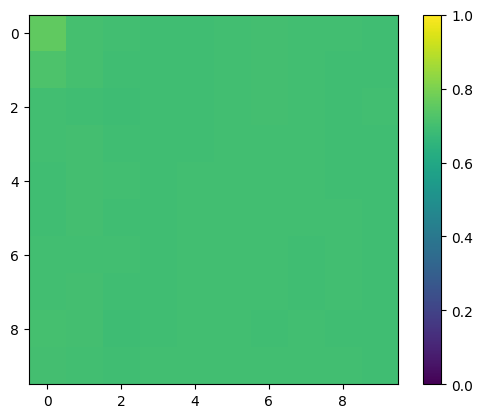

1111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111

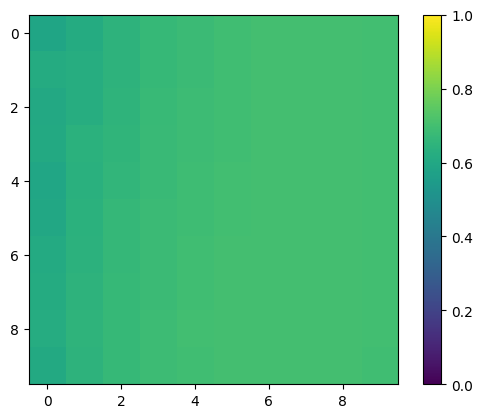

In [10]:

grid=[]
similarity =[]
distance=[]
population=[]
init_grid(grid,similarity,distance,GRID_SIZE)
init_population(population,grid)
calc_similarity(grid,population,similarity)
plot_grid(similarity)
for t in range(3):
    migrate(grid,population,similarity)
    calc_similarity(grid,population,similarity)
plot_grid(similarity)



In [291]:
similarity

[[0.5161290322580645,
  0.6382022471910113,
  0.6802507836990596,
  0.694708276797829,
  0.6954545454545454,
  0.7,
  0.6983012087553088,
  0.7038020687727146,
  0.7035500792973038,
  0.7021253405994551],
 [0.5833333333333334,
  0.6477857878475798,
  0.6832174776564052,
  0.6946714612618503,
  0.6959509202453987,
  0.6995332555425904,
  0.7002251527822451,
  0.7045360540466014,
  0.7036234501023233,
  0.7015554115359689],
 [0.6280193236714976,
  0.6638655462184874,
  0.6843588539220291,
  0.6940322071360909,
  0.6967017208413002,
  0.6991807963421605,
  0.6994164958208484,
  0.7052274270196877,
  0.7045319376709884,
  0.7006314888151557],
 [0.654485049833887,
  0.6669505962521295,
  0.683459652251449,
  0.6951219512195121,
  0.6981395348837209,
  0.6995348837209302,
  0.700604370060437,
  0.7052433954673462,
  0.7046656481372664,
  0.6998730964467005],
 [0.6519480519480519,
  0.6689868522815159,
  0.6863829787234043,
  0.6968527315914489,
  0.6993878939016096,
  0.7001818181818181,
  0